# Exploratory Data Analysis (EDA)

In this notebook we explore the relationships between different features in the dataset.

The objectives of this step are:

- Understand feature distributions
- Identify relationships with the target variable
- Detect potential outliers
- Discover important predictors for house prices

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sys.path.append(os.path.abspath(".."))

## Load Dataset

In [3]:
df = pd.read_csv("../data/raw/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Correlation Matrix

We compute correlations between numerical features to understand how they relate to each other and to the target variable.

In [4]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982


## Correlation with SalePrice

In [5]:
corr_with_target = corr_matrix["SalePrice"].sort_values(ascending=False)

corr_with_target.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

## Top Features Correlated with SalePrice

In [6]:
corr_with_target.tail(10)

BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

## Correlation Heatmap

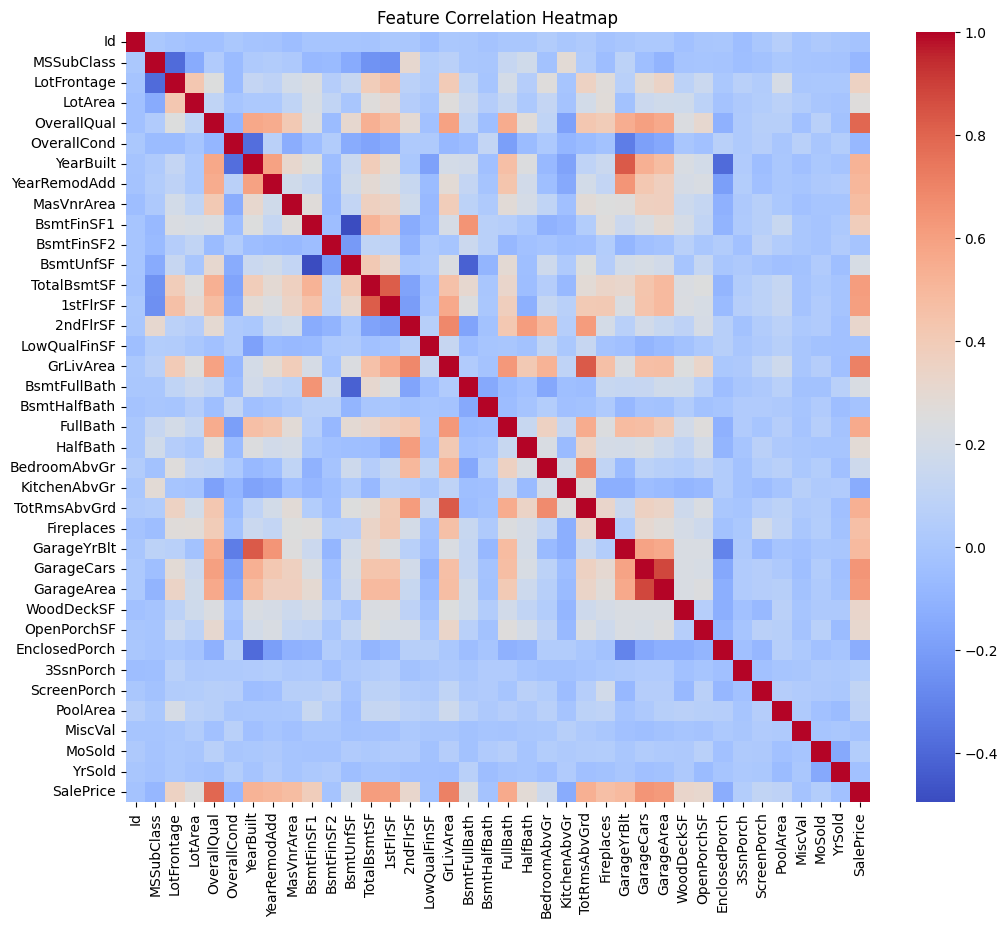

In [7]:
plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

## Scatter Plot: Living Area vs SalePrice

One of the most correlated features with SalePrice is `GrLivArea`.
We visualize the relationship between living area and sale price.

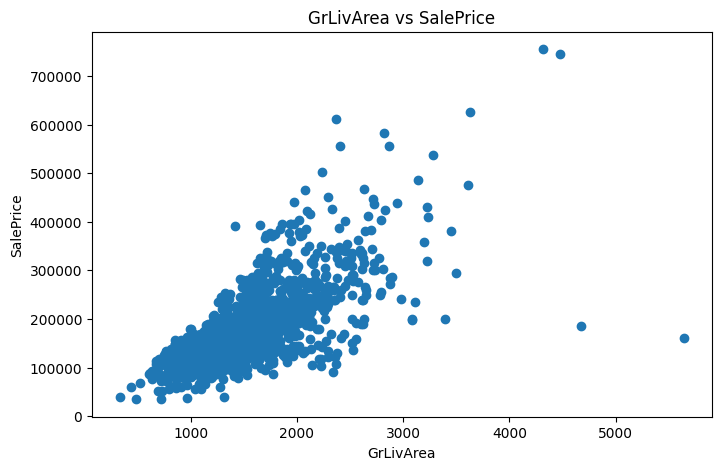

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.title("GrLivArea vs SalePrice")

plt.show()

## Distribution of Important Features

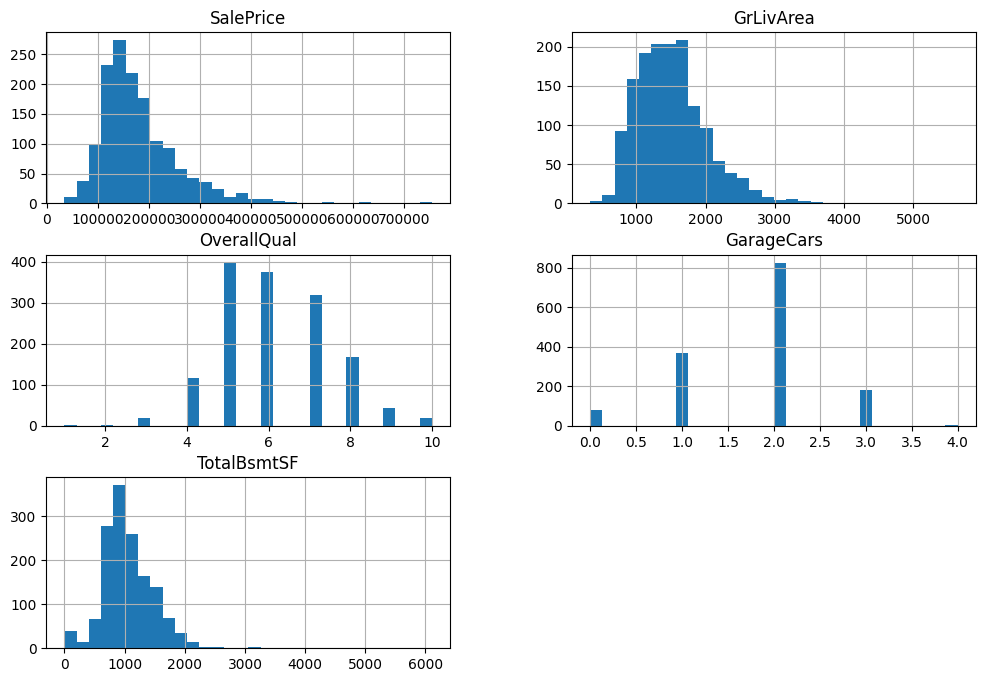

In [9]:
important_features = ["SalePrice","GrLivArea","OverallQual","GarageCars","TotalBsmtSF"]

df[important_features].hist(bins=30, figsize=(12,8))

plt.show()

## Boxplot: Overall Quality vs SalePrice

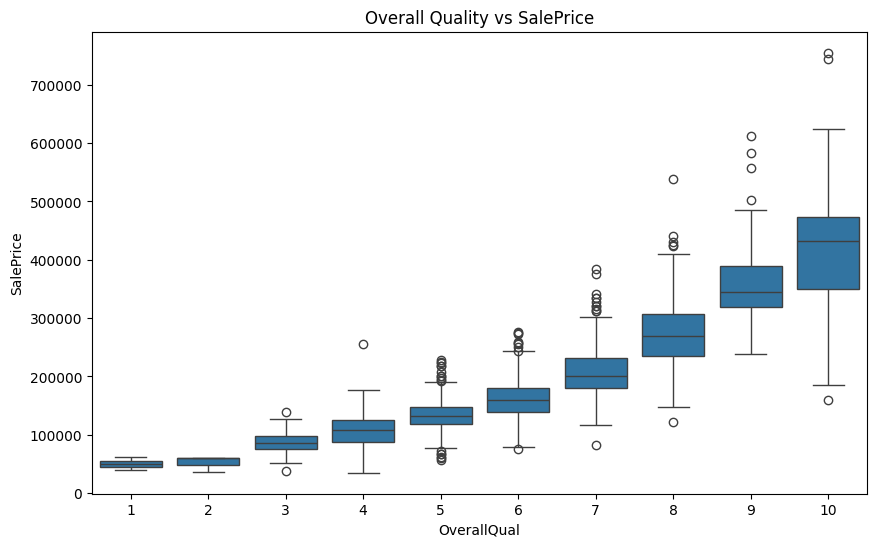

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(x="OverallQual", y="SalePrice", data=df)

plt.title("Overall Quality vs SalePrice")

plt.show()

## Observations

From the exploratory analysis:

- `OverallQual` appears strongly correlated with house prices.
- `GrLivArea` shows a clear positive relationship with `SalePrice`.
- Some features may contain outliers.
- Several numerical features show strong predictive potential.

These insights will guide the feature engineering and modeling steps.